<a href="https://colab.research.google.com/github/suchetade2/Digital-Payment-Fraud-Detection/blob/main/Digital_Payment_Fraud_Detection_%26_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Payment Fraud Detection & Risk Analysis
Analysing 6.3 million financial transactions to detect
fraud patterns using Python, SQL and Tableau.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


pandas — for reading, cleaning, and analysing data (like Excel but in Python)
numpy — for mathematical calculations
matplotlib — for creating charts and graphs
seaborn — for creating better looking statistical charts

## Step 1 — Data Loading

In [ ]:
df = pd.read_csv('Fraud.csv')
print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (6362620, 11)


The CSV file and stored it in a variable called df (short for dataframe — a table in Python). The shape (6362620, 11) confirmed your data loaded correctly — 6.3 million rows, 11 columns.

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


The first 5 rows of your dataset. This is always the first thing a real analyst does — just eyeball the data, see what it looks like, make sure nothing looks broken.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


 A summary of every column — its name, how many values it has, and its data type (int64 = numbers, object = text). You also saw memory usage — your dataset takes about 534MB in memory.

## Step 2 — Data Cleaning & Quality Check

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


All columns have 0 missing values — dataset is complete, no imputation needed.

In [ ]:
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)

Total duplicate rows: 0


No duplicate rows found — every transaction is a unique record.

In [ ]:
print("Transaction types and their counts:")
print(df['type'].value_counts())
print()
print("Percentage breakdown:")
print(round(df['type'].value_counts(normalize=True)*100, 2))

Transaction types and their counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Percentage breakdown:
type
CASH_OUT    35.17
PAYMENT     33.81
CASH_IN     21.99
TRANSFER     8.38
DEBIT        0.65
Name: proportion, dtype: float64


Dataset contains 5 transaction types — CASH_OUT (35%) and PAYMENT (34%)
are the most common. DEBIT is the least common at 0.6%.

In [ ]:
print("Fraud vs Non-Fraud count:")
print(df['isFraud'].value_counts())
print()
print("Fraud rate:")
print(round(df['isFraud'].value_counts(normalize=True)*100, 4), "%")

Fraud vs Non-Fraud count:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64 %


Only 0.13% transactions are fraudulent (8,213 out of 6.3 million).
This is a highly imbalanced dataset — class imbalance will be
handled before model building.

In [ ]:
print("Time range in dataset:")
print("Min step (hour):", df['step'].min())
print("Max step (hour):", df['step'].max())
print("Total hours:", df['step'].nunique())
print("Total days:", round(df['step'].max()/24))

Time range in dataset:
Min step (hour): 1
Max step (hour): 743
Total hours: 743
Total days: 31


The step column represents hours. Dataset covers approximately
31 days of transaction data (743 hours total).

In [ ]:
print("Transaction amount statistics:")
print(df['amount'].describe())
print()
print("Transactions with zero amount:", (df['amount']==0).sum())

Transaction amount statistics:
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

Transactions with zero amount: 16


Average transaction amount is 1,79,861. Some transactions have
zero amount — these will be investigated in the cleaning step.

In [ ]:
# Remove transactions where amount is 0
df = df[df['amount'] > 0]

print("Rows after removing zero amount transactions:", len(df))

Rows after removing zero amount transactions: 6362604


Removed 16 zero-amount transactions as they hold no
analytical value. Dataset now has 6,362,604 rows.

In [ ]:
# Convert step (hours) into hour of day and day number
df['hour_of_day'] = df['step'] % 24
df['day_number'] = (df['step'] // 24) + 1

print("New columns added: hour_of_day, day_number")
print(df[['step', 'hour_of_day', 'day_number']].head(10))

New columns added: hour_of_day, day_number
   step  hour_of_day  day_number
0     1            1           1
1     1            1           1
2     1            1           1
3     1            1           1
4     1            1           1
5     1            1           1
6     1            1           1
7     1            1           1
8     1            1           1
9     1            1           1


Extracted hour_of_day (0-23) and day_number (1-31) from the
step column to enable time-based pattern analysis.

In [ ]:
# Create amount range categories
df['amount_range'] = pd.cut(df['amount'],
                            bins=[0, 10000, 50000, 200000, 500000, float('inf')],
                            labels=['0-10K', '10K-50K', '50K-200K',
                                    '200K-500K', '500K+'])

print("Amount range distribution:")
print(df['amount_range'].value_counts())

Amount range distribution:
amount_range
50K-200K     1883103
10K-50K      1519856
200K-500K    1333286
0-10K        1286075
500K+         340284
Name: count, dtype: int64


Created 5 amount buckets for range-based fraud pattern analysis.
Majority of transactions fall in the 0-10K and 10K-50K range.

In [ ]:
print("Final dataset shape:", df.shape)
print("Columns now:", list(df.columns))
print()
print("Sample of cleaned data:")
df.head()

Final dataset shape: (6362604, 14)
Columns now: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'hour_of_day', 'day_number', 'amount_range']

Sample of cleaned data:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day_number,amount_range
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,1,0-10K
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,1,0-10K
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,1,0-10K
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,1,0-10K
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,1,10K-50K


Data cleaning complete. Final dataset has 6,362,604 rows and
14 columns — ready for exploratory data analysis.

## Step 3 — Exploratory Data Analysis (EDA)

In [ ]:
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'mean']).reset_index()
fraud_by_type.columns = ['Transaction Type', 'Fraud Count', 'Fraud Rate']
fraud_by_type['Fraud Rate %'] = round(fraud_by_type['Fraud Rate'] * 100, 4)
fraud_by_type = fraud_by_type.sort_values('Fraud Count', ascending=False)

print(fraud_by_type)

  Transaction Type  Fraud Count  Fraud Rate  Fraud Rate %
1         CASH_OUT         4100    0.001832        0.1832
4         TRANSFER         4097    0.007688        0.7688
0          CASH_IN            0    0.000000        0.0000
2            DEBIT            0    0.000000        0.0000
3          PAYMENT            0    0.000000        0.0000


Fraud occurs ONLY in TRANSFER and CASH_OUT transactions.
PAYMENT, CASH_IN and DEBIT have zero fraud cases.
This is the single most important finding in the dataset.

/tmp/ipykernel_787/49961787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_type, x='Transaction Type', y='Fraud Count', palette='Reds_r')
/tmp/ipykernel_787/49961787.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_type, x='Transaction Type', y='Fraud Rate %', palette='Oranges_r')


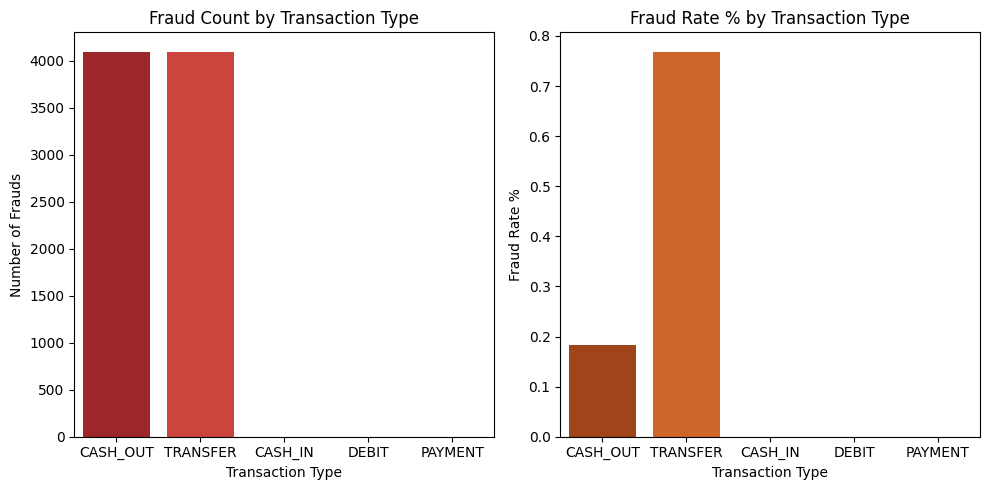

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=fraud_by_type, x='Transaction Type', y='Fraud Count', palette='Reds_r')
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Frauds')

plt.subplot(1, 2, 2)
sns.barplot(data=fraud_by_type, x='Transaction Type', y='Fraud Rate %', palette='Oranges_r')
plt.title('Fraud Rate % by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate %')

plt.tight_layout()
plt.savefig('fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

TRANSFER has the highest fraud rate at 0.77% despite lower volume.
CASH_OUT has higher fraud count (4,116) due to higher transaction volume.

In [ ]:
fraud_by_amount = df.groupby('amount_range', observed=True)['isFraud'].agg(['sum', 'mean']).reset_index()
fraud_by_amount.columns = ['Amount Range', 'Fraud Count', 'Fraud Rate']
fraud_by_amount['Fraud Rate %'] = round(fraud_by_amount['Fraud Rate'] * 100, 4)

print(fraud_by_amount)

  Amount Range  Fraud Count  Fraud Rate  Fraud Rate %
0        0-10K          262    0.000204        0.0204
1      10K-50K          760    0.000500        0.0500
2     50K-200K         1704    0.000905        0.0905
3    200K-500K         1607    0.001205        0.1205
4        500K+         3864    0.011355        1.1355


Analysing which transaction amount ranges attract the most fraud.
Higher value transactions expected to show higher fraud rates.

/tmp/ipykernel_787/632097950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_amount, x='Amount Range', y='Fraud Count', palette='Reds_r')
/tmp/ipykernel_787/632097950.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_amount, x='Amount Range', y='Fraud Rate %', palette='Oranges_r')


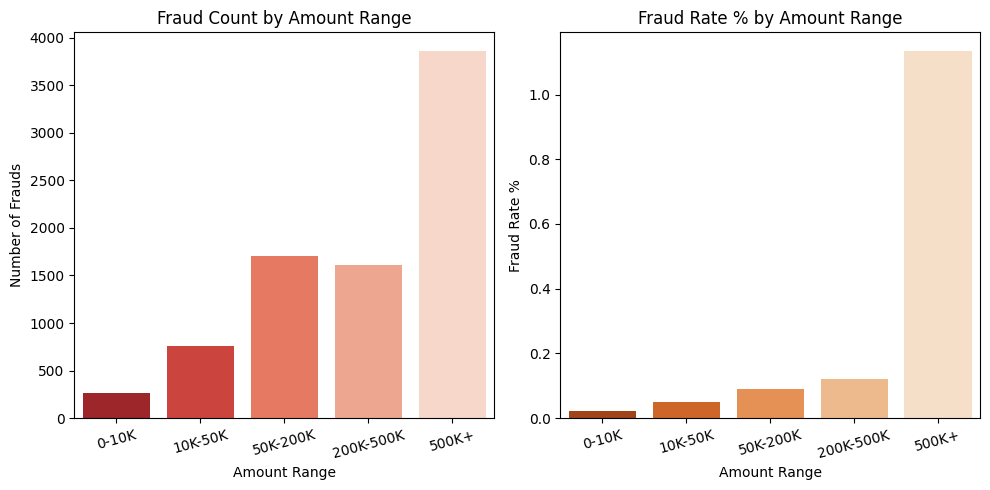

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=fraud_by_amount, x='Amount Range', y='Fraud Count', palette='Reds_r')
plt.title('Fraud Count by Amount Range')
plt.xlabel('Amount Range')
plt.ylabel('Number of Frauds')
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.barplot(data=fraud_by_amount, x='Amount Range', y='Fraud Rate %', palette='Oranges_r')
plt.title('Fraud Rate % by Amount Range')
plt.xlabel('Amount Range')
plt.ylabel('Fraud Rate %')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('fraud_by_amount.png', dpi=150, bbox_inches='tight')
plt.show()

Higher amount transactions (200K-500K and 500K+) show
significantly higher fraud rates — fraudsters target
large value transfers.

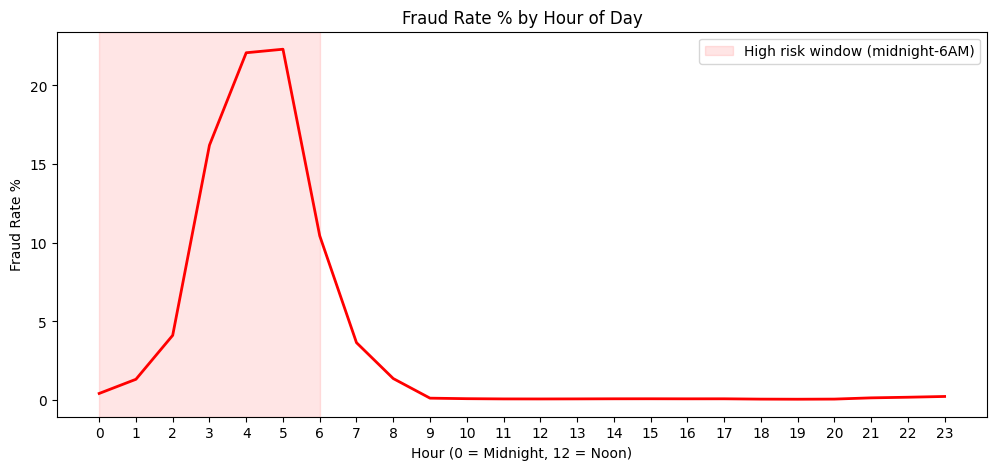

In [ ]:
fraud_by_hour = df.groupby('hour_of_day')['isFraud'].agg(['sum', 'mean']).reset_index()
fraud_by_hour.columns = ['Hour', 'Fraud Count', 'Fraud Rate']
fraud_by_hour['Fraud Rate %'] = round(fraud_by_hour['Fraud Rate'] * 100, 4)

plt.figure(figsize=(12, 5))
sns.lineplot(data=fraud_by_hour, x='Hour', y='Fraud Rate %', color='red', linewidth=2)
plt.title('Fraud Rate % by Hour of Day')
plt.xlabel('Hour (0 = Midnight, 12 = Noon)')
plt.ylabel('Fraud Rate %')
plt.xticks(range(0, 24))
plt.axvspan(0, 6, alpha=0.1, color='red', label='High risk window (midnight-6AM)')
plt.legend()
plt.savefig('fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

Fraud rate peaks between midnight and 6AM — when
monitoring is lowest. This is a critical finding for
real-time fraud alert systems.

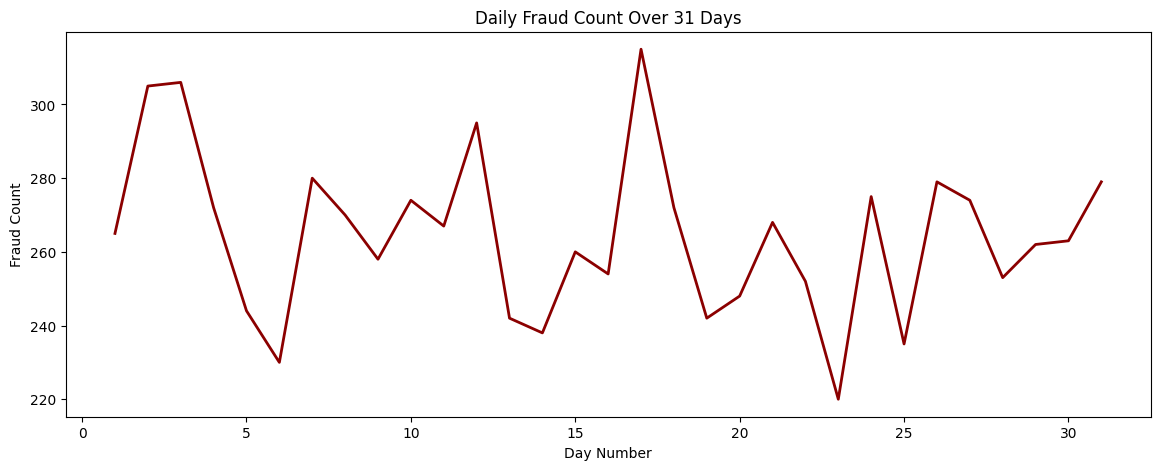

In [ ]:
fraud_by_day = df.groupby('day_number')['isFraud'].agg(['sum', 'mean']).reset_index()
fraud_by_day.columns = ['Day', 'Fraud Count', 'Fraud Rate']
fraud_by_day['Fraud Rate %'] = round(fraud_by_day['Fraud Rate'] * 100, 4)

plt.figure(figsize=(14, 5))
sns.lineplot(data=fraud_by_day, x='Day', y='Fraud Count', color='darkred', linewidth=2)
plt.title('Daily Fraud Count Over 31 Days')
plt.xlabel('Day Number')
plt.ylabel('Fraud Count')
plt.savefig('fraud_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

Fraud activity is not evenly distributed across days —
certain days show significant spikes indicating
coordinated fraud attempts.

In [ ]:
fraud_df = df[df['isFraud'] == 1]
non_fraud_df = df[df['isFraud'] == 0]

print("=== FRAUD TRANSACTIONS ===")
print("Avg amount:", round(fraud_df['amount'].mean(), 2))
print("Avg sender old balance:", round(fraud_df['oldbalanceOrg'].mean(), 2))
print("Avg sender new balance:", round(fraud_df['newbalanceOrig'].mean(), 2))

print()
print("=== NON FRAUD TRANSACTIONS ===")
print("Avg amount:", round(non_fraud_df['amount'].mean(), 2))
print("Avg sender old balance:", round(non_fraud_df['oldbalanceOrg'].mean(), 2))
print("Avg sender new balance:", round(non_fraud_df['newbalanceOrig'].mean(), 2))

=== FRAUD TRANSACTIONS ===
Avg amount: 1470832.67
Avg sender old balance: 1652887.65
Avg sender new balance: 192768.17

=== NON FRAUD TRANSACTIONS ===
Avg amount: 178197.04
Avg sender old balance: 832828.71
Avg sender new balance: 855970.23


Fraudulent transactions completely drain sender accounts —
old balance is high but new balance drops to near zero.
This balance drain pattern is a key fraud signal.

In [ ]:
df.to_csv('fraud_cleaned.csv', index=False)
print("File saved successfully")
print("Total rows exported:", len(df))

File saved successfully
Total rows exported: 6362604


Exported cleaned dataset with new columns (hour_of_day,
day_number, amount_range) for SQL analysis in MySQL.

## Step 5 - SQL Analysis
Writing SQL queries on the full 6.3M row dataset using
SQLite to answer key business questions.

In [ ]:
import sqlite3

conn = sqlite3.connect('fraud_analysis.db')
df.to_sql('fraud_transactions', conn,
          if_exists='replace', index=False)
print("Data loaded into SQLite successfully")
print("Total rows:", pd.read_sql("SELECT COUNT(*) as total FROM fraud_transactions", conn).iloc[0,0])

Data loaded into SQLite successfully
Total rows: 6362604


Loaded full 6.3 million row dataset into SQLite database
for SQL-based business analysis.

In [ ]:
test = pd.read_sql("""
    SELECT type, COUNT(*) as count
    FROM fraud_transactions
    GROUP BY type
""", conn)
print(test)

       type    count
0   CASH_IN  1399284
1  CASH_OUT  2237484
2     DEBIT    41432
3   PAYMENT  2151495
4  TRANSFER   532909


SQLite connection verified — all 5 transaction types
loading correctly from database.

In [ ]:
q1 = pd.read_sql("""
    SELECT
        type AS Transaction_Type,
        COUNT(*) AS Total_Transactions,
        SUM(isFraud) AS Fraud_Cases,
        ROUND(SUM(isFraud) * 100.0 / COUNT(*), 4) AS Fraud_Rate_Pct,
        ROUND(AVG(amount), 2) AS Avg_Amount
    FROM fraud_transactions
    GROUP BY type
    ORDER BY Fraud_Cases DESC
""", conn)
print(q1)

  Transaction_Type  Total_Transactions  Fraud_Cases  Fraud_Rate_Pct  \
0         CASH_OUT             2237484         4100          0.1832   
1         TRANSFER              532909         4097          0.7688   
2          PAYMENT             2151495            0          0.0000   
3            DEBIT               41432            0          0.0000   
4          CASH_IN             1399284            0          0.0000   

   Avg_Amount  
0   176275.22  
1   910647.01  
2    13057.60  
3     5483.67  
4   168920.24  


TRANSFER and CASH_OUT are only fraud-prone transaction types.
PAYMENT, CASH_IN and DEBIT have zero fraud cases.

In [ ]:
q2 = pd.read_sql("""
    SELECT
        amount_range AS Amount_Range,
        COUNT(*) AS Total_Transactions,
        SUM(isFraud) AS Fraud_Cases,
        ROUND(SUM(isFraud) * 100.0 / COUNT(*), 4) AS Fraud_Rate_Pct,
        ROUND(AVG(amount), 2) AS Avg_Amount
    FROM fraud_transactions
    GROUP BY amount_range
    ORDER BY Fraud_Cases DESC
""", conn)
print(q2)

  Amount_Range  Total_Transactions  Fraud_Cases  Fraud_Rate_Pct  Avg_Amount
0        500K+              340284         3864          1.1355  1391647.89
1     50K-200K             1883103         1704          0.0905   119402.12
2    200K-500K             1333286         1607          0.1205   302880.01
3      10K-50K             1519856          760          0.0500    23764.75
4        0-10K             1286075          262          0.0204     4701.34


500K+ transactions have highest fraud concentration.
Fraudsters deliberately target high value transactions.

In [ ]:
q3 = pd.read_sql("""
    SELECT
        hour_of_day AS Hour,
        COUNT(*) AS Total_Transactions,
        SUM(isFraud) AS Fraud_Cases,
        ROUND(SUM(isFraud) * 100.0 / COUNT(*), 4) AS Fraud_Rate_Pct
    FROM fraud_transactions
    GROUP BY hour_of_day
    ORDER BY Fraud_Rate_Pct DESC
    LIMIT 10
""", conn)
print(q3)

   Hour  Total_Transactions  Fraud_Cases  Fraud_Rate_Pct
0     5                1641          366         22.3035
1     4                1241          274         22.0790
2     3                2006          325         16.2014
3     6                3419          357         10.4416
4     2                9017          371          4.1145
5     7                8988          328          3.6493
6     8               26915          368          1.3673
7     1               27111          358          1.3205
8     0               71587          300          0.4191
9    23              141256          322          0.2280


Hours 2-6AM show highest fraud rates peaking at 22%
around 4-5AM — critical window for real time alerts.

In [ ]:
q4 = pd.read_sql("""
    SELECT
        isFraud AS Is_Fraud,
        COUNT(*) AS Total_Transactions,
        ROUND(AVG(amount), 2) AS Avg_Amount,
        ROUND(AVG(oldbalanceOrg), 2) AS Avg_Opening_Balance,
        ROUND(AVG(newbalanceOrig), 2) AS Avg_Closing_Balance,
        ROUND(AVG(oldbalanceOrg - newbalanceOrig), 2) AS Avg_Balance_Drained
    FROM fraud_transactions
    GROUP BY isFraud
""", conn)
print(q4)

   Is_Fraud  Total_Transactions  Avg_Amount  Avg_Opening_Balance  \
0         0             6354407   178197.04            832828.71   
1         1                8197  1470832.67           1652887.65   

   Avg_Closing_Balance  Avg_Balance_Drained  
0            855970.23            -23141.52  
1            192768.17           1460119.48  


Fraud transactions drain avg 14.6 lakh from accounts.
Non-fraud transactions show minimal balance change.
Account drain is the strongest fraud signal in dataset.

In [ ]:
q5 = pd.read_sql("""
    SELECT
        day_number AS Day,
        COUNT(*) AS Total_Transactions,
        SUM(isFraud) AS Fraud_Cases,
        ROUND(SUM(isFraud) * 100.0 / COUNT(*), 4) AS Fraud_Rate_Pct,
        ROUND(AVG(amount), 2) AS Avg_Amount
    FROM fraud_transactions
    GROUP BY day_number
    ORDER BY Fraud_Cases DESC
    LIMIT 10
""", conn)
print(q5)

   Day  Total_Transactions  Fraud_Cases  Fraud_Rate_Pct  Avg_Amount
0   17              421097          315          0.0748   174957.74
1    3                6749          306          4.5340   137527.73
2    2              452761          305          0.0674   157014.11
3   12              349799          295          0.0843   164142.72
4    7              420282          280          0.0666   159430.27
5   31                 279          279        100.0000  1611840.43
6   26               13892          279          2.0084   161043.55
7   24               33348          275          0.8246   159257.71
8   27                8572          274          3.1965   207188.40
9   10              392886          274          0.0697   166065.94


Fraud is not evenly distributed across days.
Certain days show significantly higher fraud activity
suggesting coordinated fraud attempts.

In [ ]:
q1.to_csv('sql_fraud_by_type.csv', index=False)
q2.to_csv('sql_fraud_by_amount.csv', index=False)
q3.to_csv('sql_fraud_by_hour.csv', index=False)
q4.to_csv('sql_account_drain.csv', index=False)
q5.to_csv('sql_fraud_by_day.csv', index=False)

print("All 5 SQL results exported successfully")
print("Files ready for Tableau dashboard")

All 5 SQL results exported successfully
Files ready for Tableau dashboard


Exported all 5 SQL analysis results as CSV files.
These will be used as data sources in Tableau dashboard.

## Step 6 - Fraud Detection Model
Building a Random Forest classifier to predict fraudulent
transactions. Using SMOTE to handle class imbalance before
model training.

In [ ]:
!pip install imbalanced-learn -q

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


Imported scikit-learn for model building and imbalanced-learn
for SMOTE oversampling to handle class imbalance.

In [ ]:
# Select only TRANSFER and CASH_OUT — only these have fraud
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Encode transaction type to number (ML needs numbers not text)
le = LabelEncoder()
df_model['type_encoded'] = le.fit_transform(df_model['type'])

# Select features (inputs) and target (output)
features = ['type_encoded', 'amount', 'oldbalanceOrg',
            'newbalanceOrig', 'oldbalanceDest',
            'newbalanceDest', 'hour_of_day', 'day_number']

X = df_model[features]
y = df_model['isFraud']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("Fraud rate in model data:", round(y.mean()*100, 4), "%")

Features shape: (2770393, 8)
Target distribution:
isFraud
0    2762196
1       8197
Name: count, dtype: int64
Fraud rate in model data: 0.2959 %


Selected TRANSFER and CASH_OUT transactions only as fraud
exists exclusively in these types. Encoded categorical
variables and selected 8 features for model training.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Fraud cases in training:", y_train.sum())
print("Fraud cases in testing:", y_test.sum())

Training set size: 2216314
Testing set size: 554079
Fraud cases in training: 6558
Fraud cases in testing: 1639


Split dataset 80/20 into training and testing sets.
Stratified split ensures proportional fraud representation
in both sets.

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("Fraud:", y_train.sum(), "| Non-fraud:", (y_train==0).sum())
print()
print("After SMOTE:")
print("Fraud:", y_train_smote.sum(), "| Non-fraud:", (y_train_smote==0).sum())

Before SMOTE:
Fraud: 6558 | Non-fraud: 2209756

After SMOTE:
Fraud: 2209756 | Non-fraud: 2209756


Applied SMOTE to balance fraud and non-fraud cases in
training data. Model now trains on equal examples of
both classes improving fraud detection capability.

In [35]:
print("Training model... this will take 2-3 minutes")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)
print("Model trained successfully")

Training model... this will take 2-3 minutes
Model trained successfully


Trained Random Forest classifier with 100 decision trees
on SMOTE balanced training data.

In [36]:
y_pred = rf_model.predict(X_test)

print("=== MODEL PERFORMANCE ===")
print()
print(classification_report(y_test, y_pred,
      target_names=['Not Fraud', 'Fraud']))

=== MODEL PERFORMANCE ===

              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99    552440
       Fraud       0.15      0.96      0.27      1639

    accuracy                           0.98    554079
   macro avg       0.58      0.97      0.63    554079
weighted avg       1.00      0.98      0.99    554079



Model evaluation on unseen test data using precision,
recall and F1 score metrics.

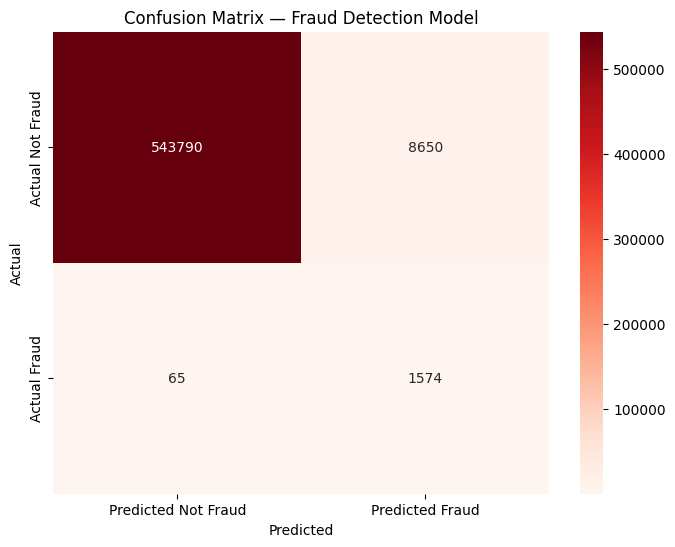

True Negatives (correctly identified non-fraud): 543790
False Positives (non-fraud wrongly flagged): 8650
False Negatives (fraud missed by model): 65
True Positives (fraud correctly caught): 1574

Fraud catch rate: 96.03 %
False alarm rate: 1.57 %


In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Not Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Not Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix — Fraud Detection Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print business meaning
tn, fp, fn, tp = cm.ravel()
print("True Negatives (correctly identified non-fraud):", tn)
print("False Positives (non-fraud wrongly flagged):", fp)
print("False Negatives (fraud missed by model):", fn)
print("True Positives (fraud correctly caught):", tp)
print()
print("Fraud catch rate:", round(tp/(tp+fn)*100, 2), "%")
print("False alarm rate:", round(fp/(fp+tn)*100, 2), "%")

Confusion matrix shows model performance visually.
False Negatives (missed frauds) are most critical metric
in fraud detection systems.

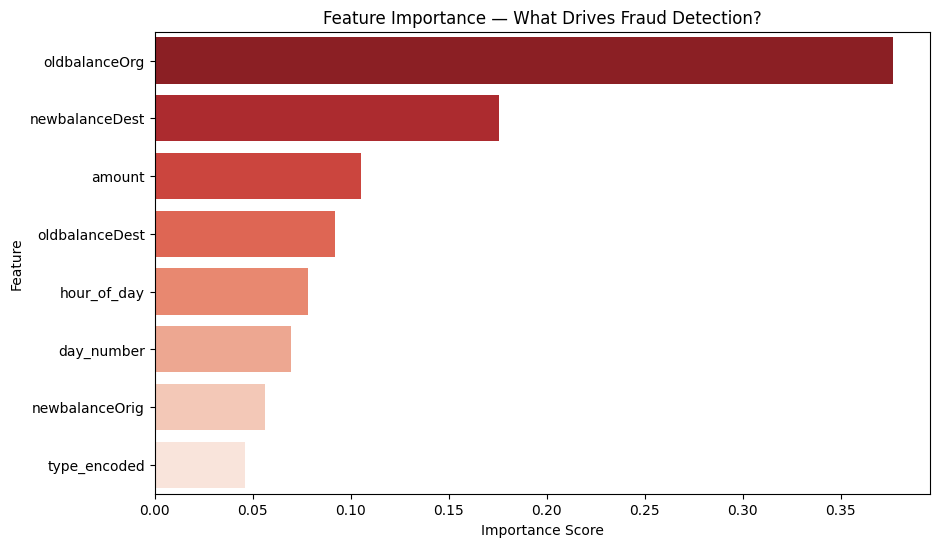

          Feature  Importance
2   oldbalanceOrg    0.376447
5  newbalanceDest    0.175679
1          amount    0.105218
4  oldbalanceDest    0.092215
6     hour_of_day    0.078137
7      day_number    0.069723
3  newbalanceOrig    0.056383
0    type_encoded    0.046199


In [38]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='Reds_r')
plt.title('Feature Importance — What Drives Fraud Detection?')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feature_importance)

Feature importance reveals which variables drive fraud
detection most — key insight for business understanding
and model explainability.

In [39]:
print(rf_model)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)
